#Md Alamgir Hossain, PMP, CSM, ITILv5
##BIS, Saskatchewan Polytechnic

# Lab Exercise 1: Classification with the Wine Dataset

**Objective:** Build and evaluate a classifier that predicts the wine cultivar from 13 chemical measurements.

This is a **supervised, multiclass classification** problem because every sample has a known class label and there are three possible categories.

## Exercise analysis

The exercise tests the standard classification pipeline:

1. Load a labeled dataset and identify its features and target.
2. Explore its size, data types, missing values, and class distribution.
3. Visualize a few useful features to see whether the classes appear separable.
4. Hold out 20% of the records so evaluation uses unseen data.
5. Fit a `DecisionTreeClassifier` to learn classification rules.
6. Evaluate predictions using accuracy, a confusion matrix, precision, recall, and F1-score.
7. Use feature importance and the evaluation results to form an evidence-based conclusion.

`random_state=42` makes the split and decision tree reproducible. `stratify=y` is added as a sound practice so all three wine classes remain proportionally represented in both sets.


## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")


## 2. Load and explore the data

In [25]:
wine = load_wine()

# Feature values become X; the known cultivar is the target y.
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

# Add readable class names for exploration and plotting.
df = X.copy()
df["class_name"] = y.map(dict(enumerate(wine.target_names)))

print("2.1 First five rows (Head of the DataFrame):")
print(df.head())
print("\nDataFrame information:")
df.info()


2.1 First five rows (Head of the DataFrame):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of

In [26]:
print("Dataset shape:", df.shape)
print("Number of feature columns:", X.shape[1])
print("Missing values:", int(df.isna().sum().sum()))
print("\n2.2 Samples per wine class:")
print(df["class_name"].value_counts().sort_index())


Dataset shape: (178, 14)
Number of feature columns: 13
Missing values: 0

2.2 Samples per wine class:
class_name
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


### Exploration finding

The dataset contains **178 samples**, **13 predictor features**, and **one target column**. There are no missing values. The class counts are 59, 71, and 48, so the dataset is reasonably balanced, although the classes are not exactly equal.


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dimensions, columns, missing values, and duplicates

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
for column in df.columns:
    print("-", column)

print("\nMissing values in each column:")
print(df.isnull().sum())
print("\nTotal missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))


Number of rows: 178
Number of columns: 14

Column names:
- alcohol
- malic_acid
- ash
- alcalinity_of_ash
- magnesium
- total_phenols
- flavanoids
- nonflavanoid_phenols
- proanthocyanins
- color_intensity
- hue
- od280/od315_of_diluted_wines
- proline
- class_name

Missing values in each column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
class_name                      0
dtype: int64

Total missing values: 0
Duplicate rows: 0


#### Result summary

The dataset has **178 rows** and **14 columns**: 13 chemical features and one readable class column. There are no missing values or duplicate rows, so no cleaning is required before modelling.


### 3.2 Descriptive statistics

In [6]:
# Transpose the result so each feature appears on one row.
print(df.describe().T)


                              count        mean         std     min       25%  \
alcohol                       178.0   13.000618    0.811827   11.03   12.3625   
malic_acid                    178.0    2.336348    1.117146    0.74    1.6025   
ash                           178.0    2.366517    0.274344    1.36    2.2100   
alcalinity_of_ash             178.0   19.494944    3.339564   10.60   17.2000   
magnesium                     178.0   99.741573   14.282484   70.00   88.0000   
total_phenols                 178.0    2.295112    0.625851    0.98    1.7425   
flavanoids                    178.0    2.029270    0.998859    0.34    1.2050   
nonflavanoid_phenols          178.0    0.361854    0.124453    0.13    0.2700   
proanthocyanins               178.0    1.590899    0.572359    0.41    1.2500   
color_intensity               178.0    5.058090    2.318286    1.28    3.2200   
hue                           178.0    0.957449    0.228572    0.48    0.7825   
od280/od315_of_diluted_wines

#### Result summary

Among the four selected features, **proline** has the largest numerical range, from **278 to 1,680**, while **alcohol** ranges from **11.03 to 14.83**. Their mean values are **746.89** and **13.00**, respectively, so the features are measured on clearly different scales.


### 3.3 Target-class distribution

class_name
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


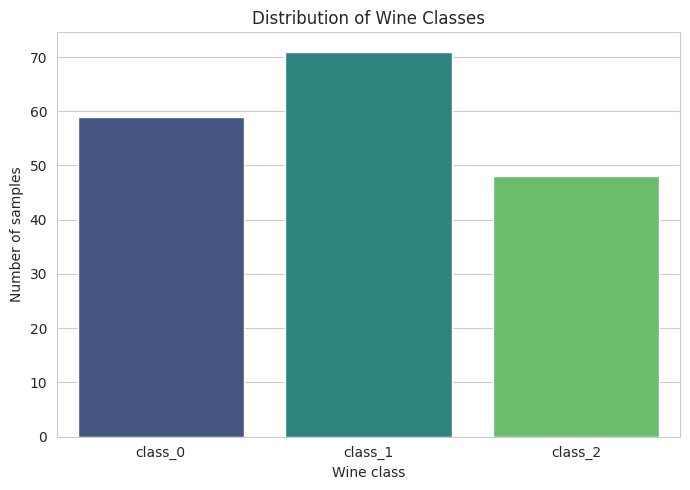

In [7]:
class_counts = df["class_name"].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="class_name",
    hue="class_name",
    palette="viridis",
    legend=False
)
plt.xlabel("Wine class")
plt.ylabel("Number of samples")
plt.title("Distribution of Wine Classes")
plt.tight_layout()
plt.show()


#### Result summary

`class_0` contains **59 samples**, `class_1` contains **71**, and `class_2` contains **48**. `class_1` is the largest class and `class_2` is the smallest, but no class is severely underrepresented.


### 3.4 Distributions of selected features

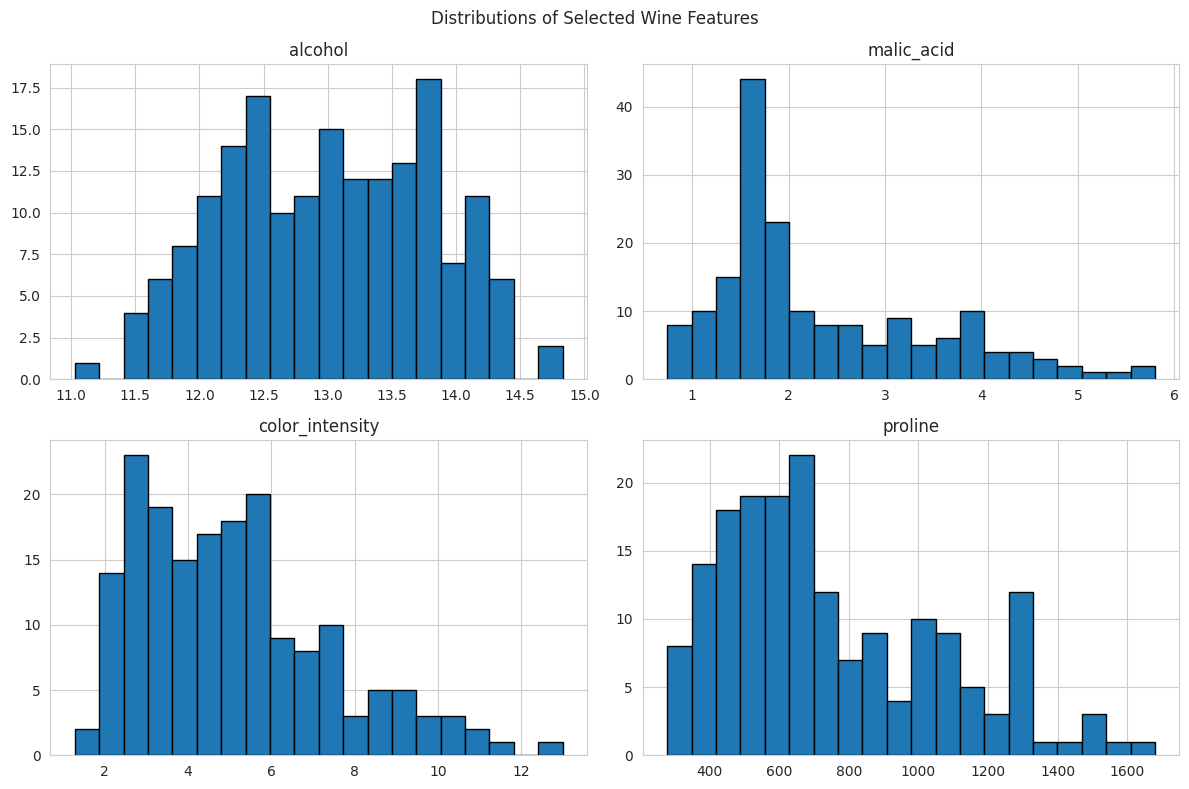

In [9]:
selected_features = ["alcohol", "malic_acid", "color_intensity", "proline"]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor="black"
)
plt.suptitle("Distributions of Selected Wine Features")
plt.tight_layout()
plt.show()


#### Result summary

**Alcohol** is concentrated around 13.0, **malic acid** around 2.34, **color intensity** around 5.06, and **proline** around 746.89. Malic acid, color intensity, and proline extend farther toward higher values, while alcohol is more tightly distributed.


### 3.5 Compare feature distributions across classes

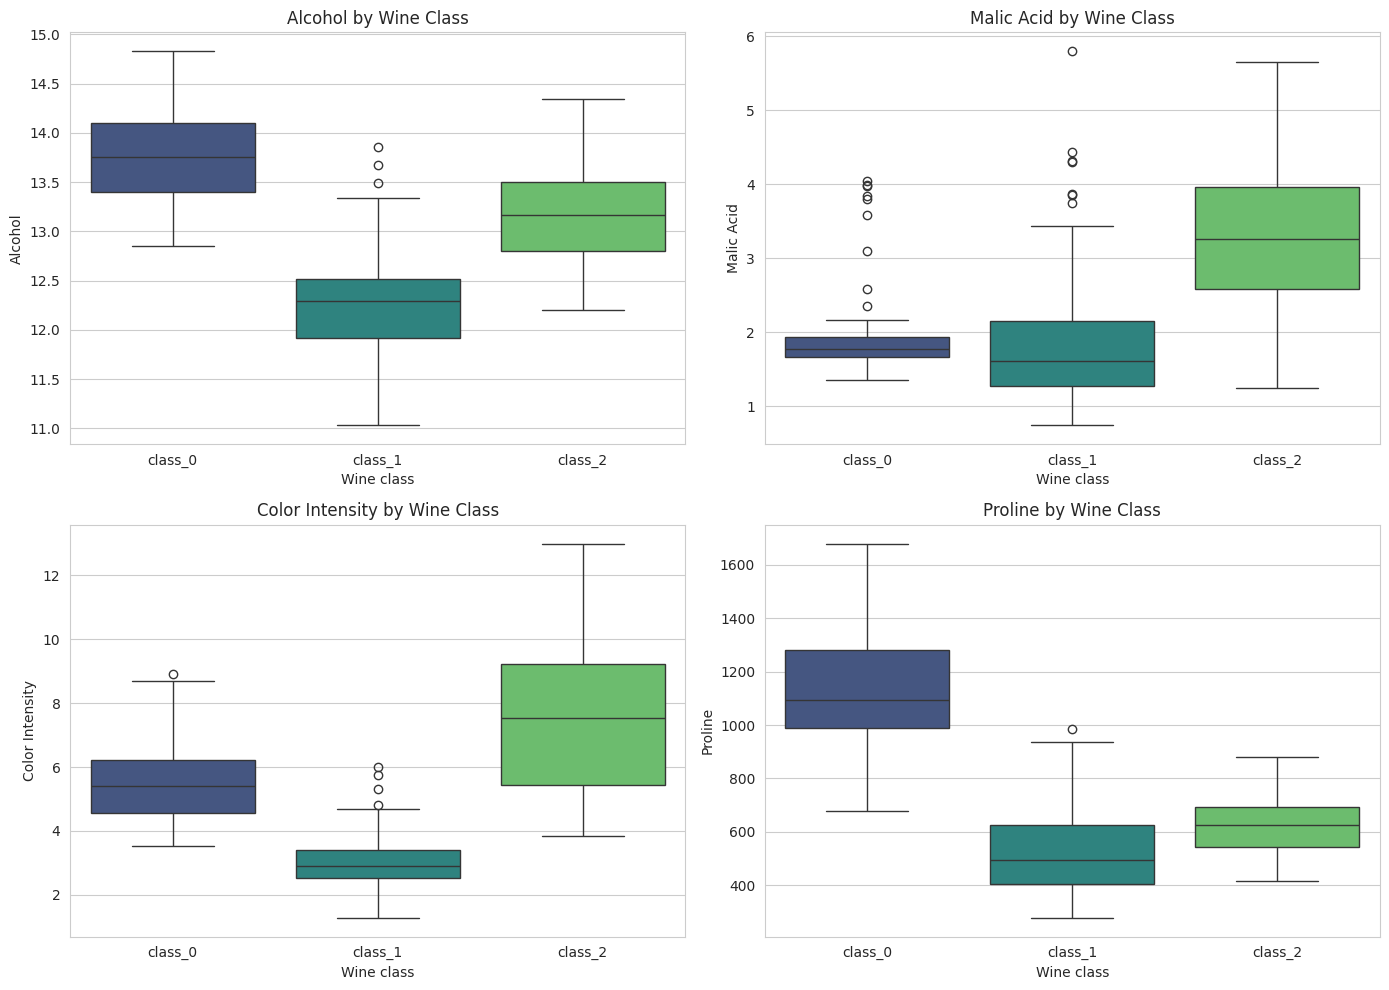

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for feature, axis in zip(selected_features, axes.flatten()):
    sns.boxplot(
        data=df,
        x="class_name",
        y=feature,
        hue="class_name",
        palette="viridis",
        legend=False,
        ax=axis
    )
    axis.set_title(f"{feature.replace('_', ' ').title()} by Wine Class")
    axis.set_xlabel("Wine class")
    axis.set_ylabel(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()


#### Result summary

`class_0` has the highest average **alcohol** (13.74) and **proline** (1,115.71). `class_2` has the highest average **malic acid** (3.33) and **color intensity** (7.40), while `class_1` has the lowest average alcohol (12.28), color intensity (3.09), and proline (519.51).


### 3.6 Pair plot of selected features

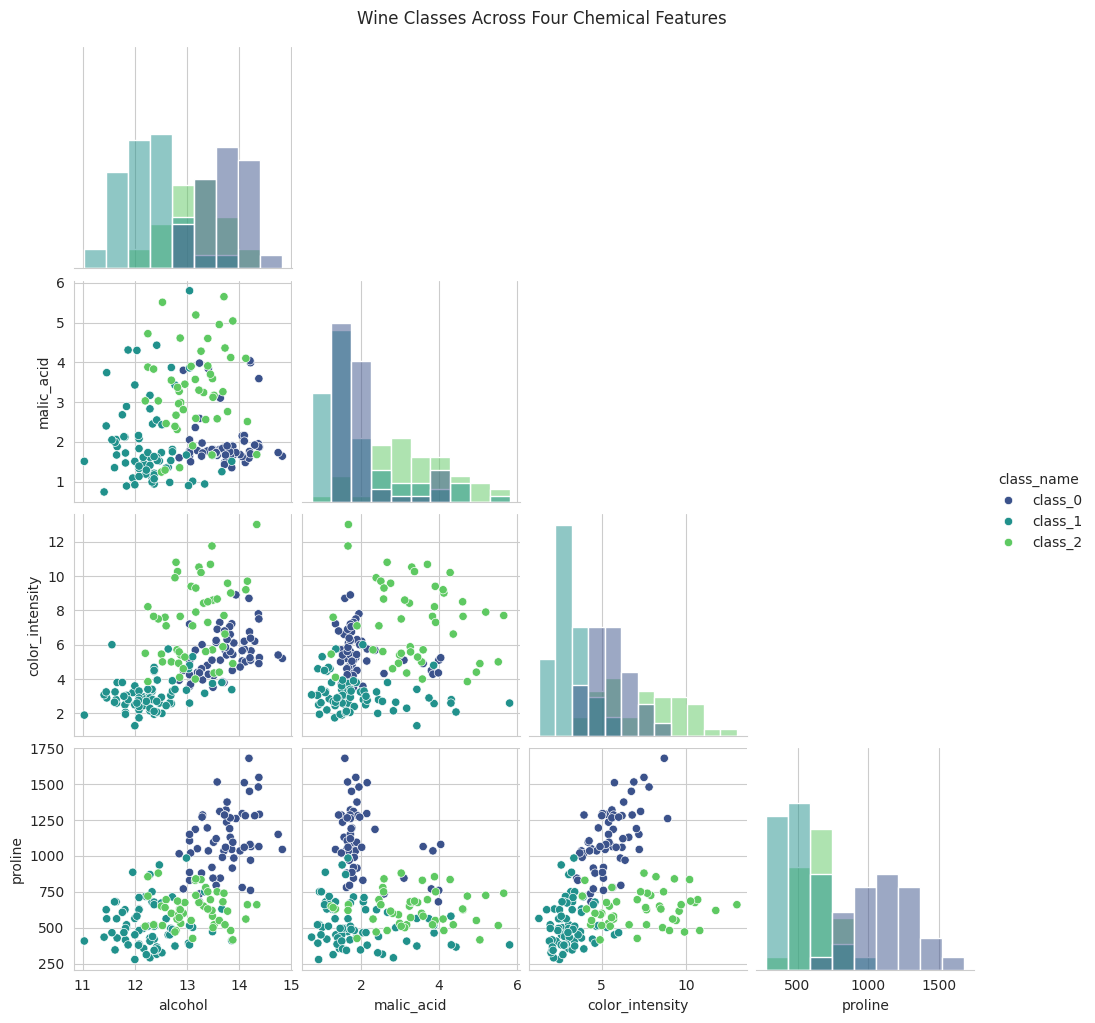

In [11]:
selected_columns = ["alcohol", "malic_acid", "color_intensity", "proline", "class_name"]

pair_grid = sns.pairplot(
    df[selected_columns],
    hue="class_name",
    corner=True,
    diag_kind="hist",
    palette="viridis"
)
pair_grid.fig.suptitle("Wine Classes Across Four Chemical Features", y=1.02)
plt.show()


### Visualization interpretation

The pair plot shows that `class_0` is generally associated with high **proline**, while `class_1` is concentrated at lower **alcohol**, **color intensity**, and **proline** values. `class_2` tends to have higher **malic acid** and **color intensity**, although some points overlap with the other classes.


### 3.7 Correlation analysis

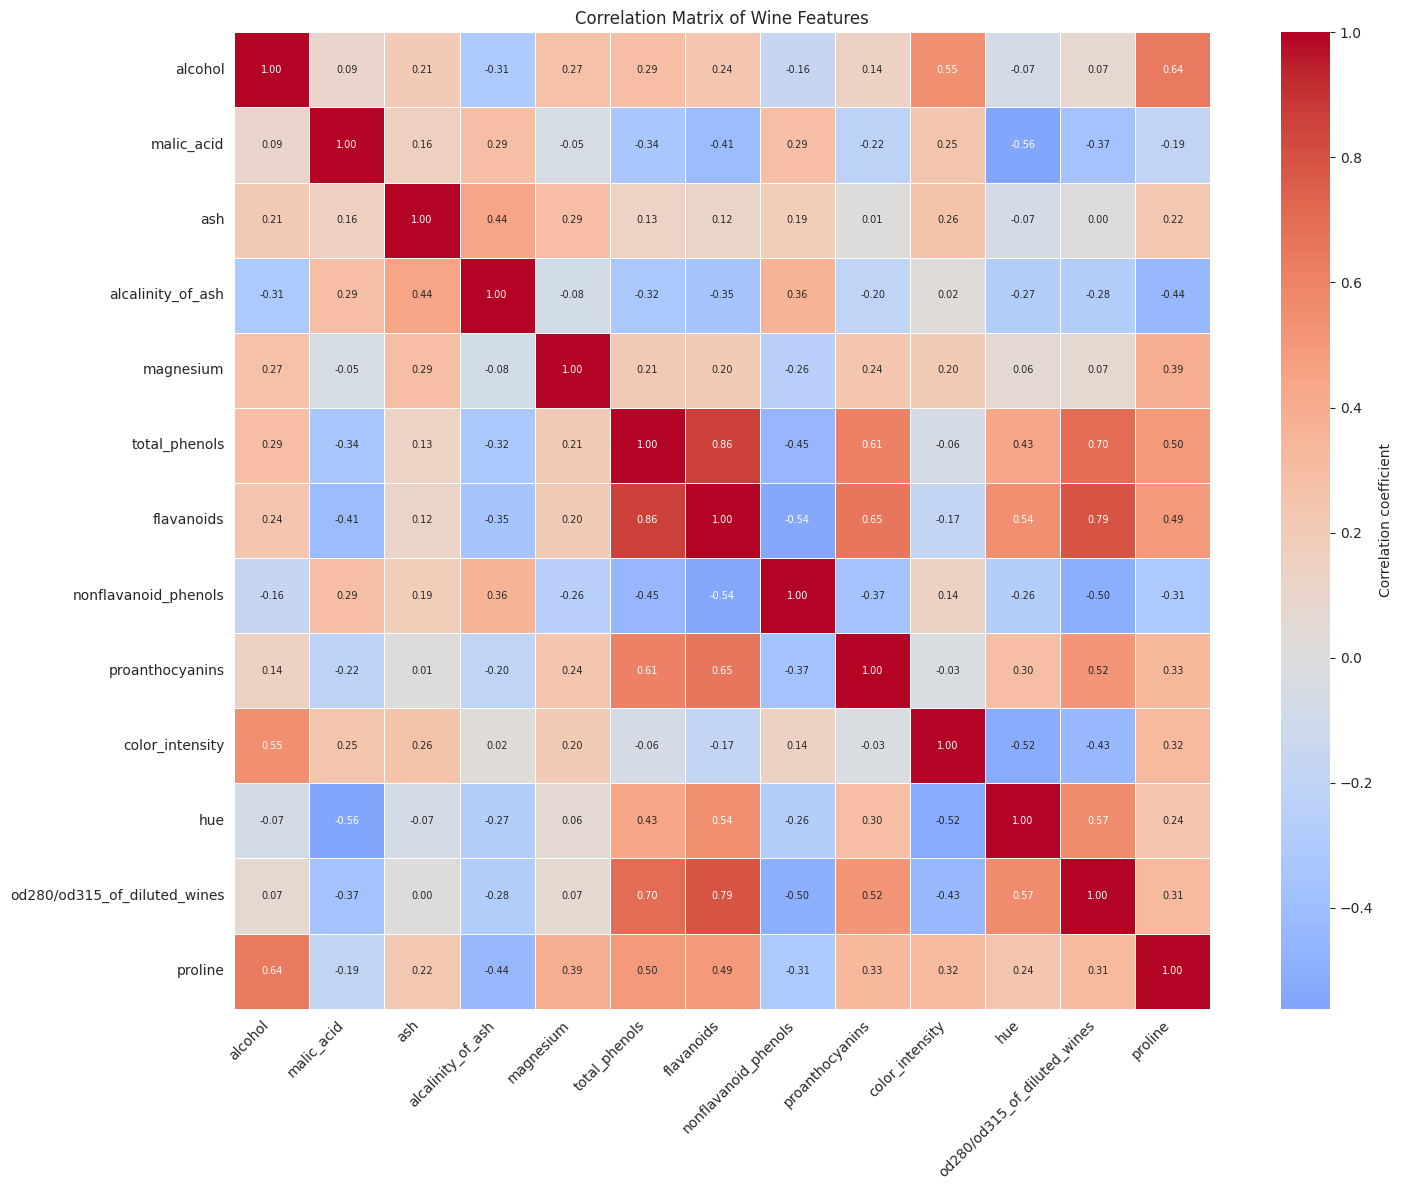

In [12]:
correlation_matrix = df[wine.feature_names].corr()

# Display the correlation value in every heatmap cell.
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation coefficient"}
)
plt.title("Correlation Matrix of Wine Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### Result summary

The strongest positive correlation is between **total phenols** and **flavanoids** (**0.865**). Other notable positive relationships are flavanoids with **OD280/OD315 of diluted wines** (**0.787**) and alcohol with **proline** (**0.644**).


### EDA findings

The Wine dataset is clean: it has no missing values and no duplicate rows. The target classes are reasonably balanced. The histograms show that features have different ranges and distributions, while the box plots and pair plot reveal useful class separation—particularly for color intensity and proline. The correlation heatmap also shows that some chemical measurements are related. The data is suitable for classification without missing-value treatment.


## 4. Prepare and split the data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nTraining class counts:")
print(y_train.value_counts().sort_index())
print("\nTesting class counts:")
print(y_test.value_counts().sort_index())


Training samples: 142
Testing samples: 36

Training class counts:
target
0    47
1    57
2    38
Name: count, dtype: int64

Testing class counts:
target
0    12
1    14
2    10
Name: count, dtype: int64


### Result summary

The training set contains **47 `class_0`**, **57 `class_1`**, and **38 `class_2`** samples. The test set contains **12 `class_0`**, **14 `class_1`**, and **10 `class_2`** samples, confirming that stratification preserved all three classes.


## 5. Train the classifier

In [14]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
print("Decision tree trained successfully.")


Decision tree trained successfully.


### Result summary

The Decision Tree learned rules using exact features such as **color intensity**, **flavanoids**, **proline**, **ash**, **malic acid**, **alcalinity of ash**, and **OD280/OD315 of diluted wines**. Its first split is based on whether color intensity is at most **3.82**.


### 5.1 Visualize the Decision Tree

Each box is a decision node or final class. Follow the left branch when the condition is true and the right branch when it is false.


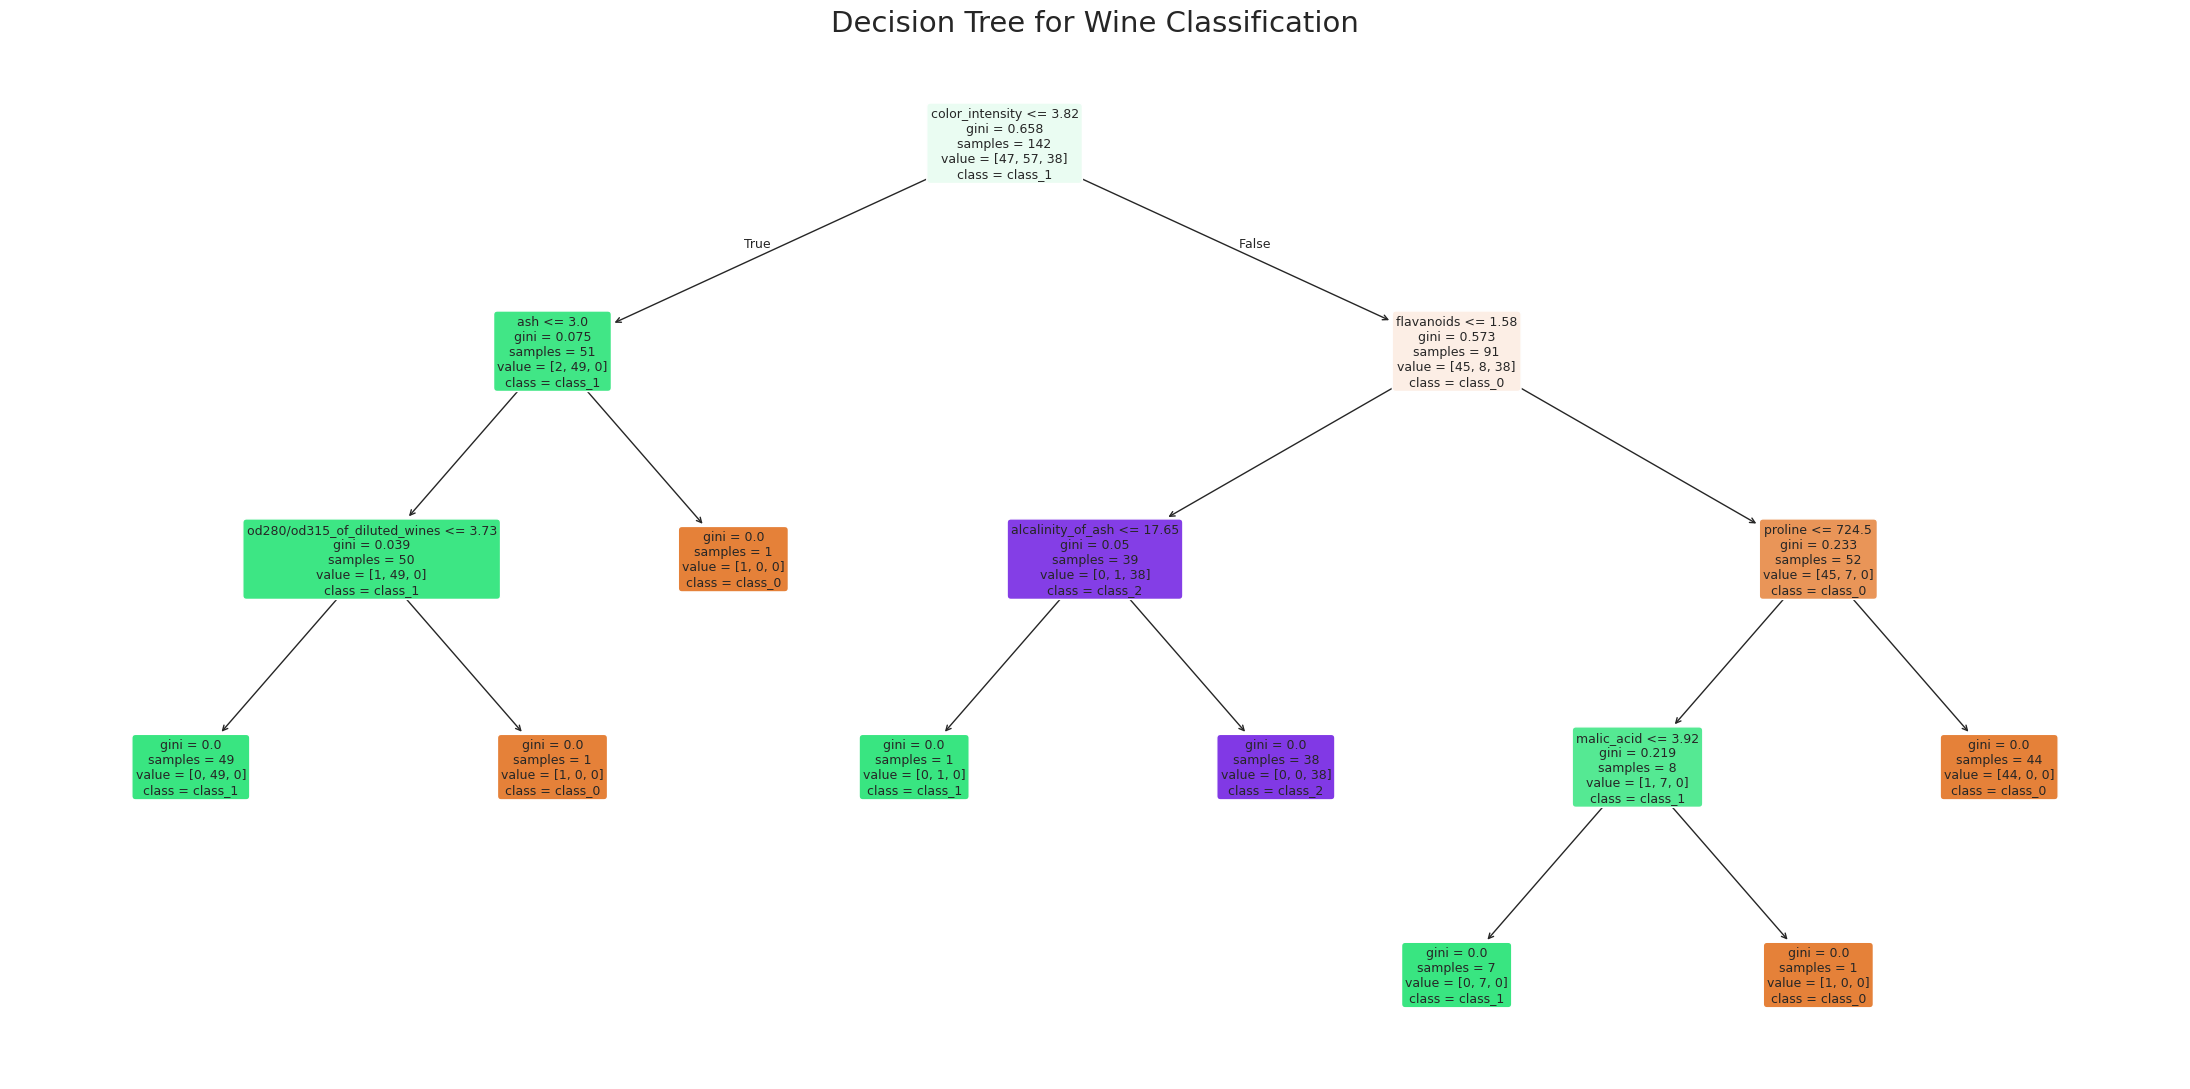

In [19]:
# Display the complete Decision Tree learned from the training data.
plt.figure(figsize=(22, 11))
plot_tree(
    model,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree for Wine Classification", fontsize=21)
plt.tight_layout()
plt.show()


### Result summary

The first rule separates wines using **color intensity ≤ 3.82**. Later branches use exact features including **ash**, **OD280/OD315 of diluted wines**, **flavanoids**, **alcalinity of ash**, **proline**, and **malic acid** to reach predictions for `class_0`, `class_1`, or `class_2`.


## 6. Evaluate the model

In [20]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")


Accuracy: 0.9444 (94.44%)


### Result summary

The model achieved **94.44% accuracy**, correctly predicting 34 of the 36 test samples. This indicates strong performance on this test split.


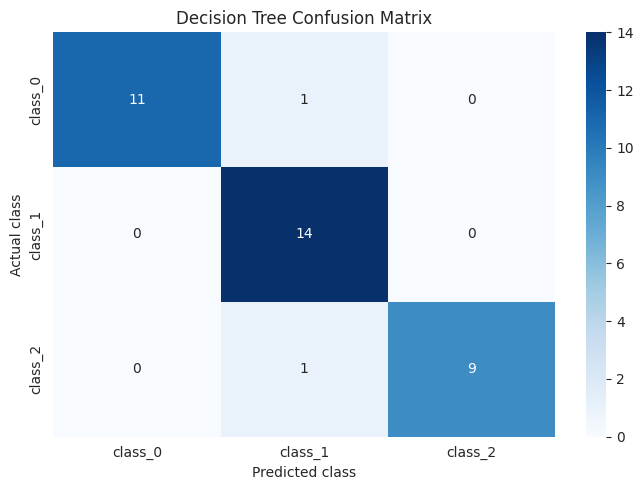

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


### Result summary

The confusion matrix shows **34 correct predictions** on the diagonal and only **2 errors**. One `class_0` sample and one `class_2` sample were predicted as `class_1`.


In [22]:
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))


Classification report:
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



### Result summary

`class_0` achieved precision **1.00**, recall **0.92**, and F1-score **0.96**. `class_1` achieved **0.88**, **1.00**, and **0.93**, while `class_2` achieved **1.00**, **0.90**, and **0.95**, respectively.


## 7. Identify the most important features

flavanoids                      0.408073
color_intensity                 0.400189
proline                         0.110985
od280/od315_of_diluted_wines    0.020986
alcalinity_of_ash               0.020865
ash                             0.020163
malic_acid                      0.018738
magnesium                       0.000000
alcohol                         0.000000
proanthocyanins                 0.000000
nonflavanoid_phenols            0.000000
total_phenols                   0.000000
hue                             0.000000
Name: importance, dtype: float64


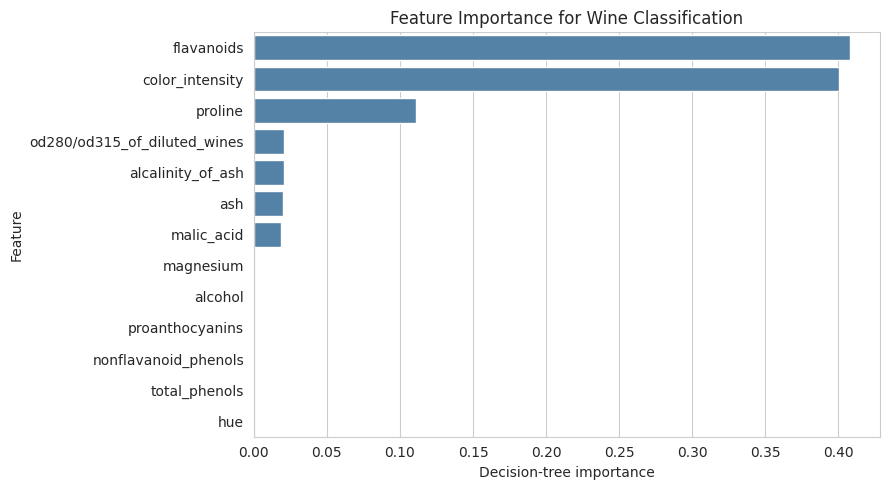

In [23]:
feature_importance = (
    pd.Series(model.feature_importances_, index=wine.feature_names, name="importance")
    .sort_values(ascending=False)
)

print(feature_importance)

plt.figure(figsize=(9, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, color="steelblue")
plt.xlabel("Decision-tree importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Wine Classification")
plt.tight_layout()
plt.show()


### Result summary

**Flavanoids** contributed **40.81%**, **color intensity** contributed **40.02%**, and **proline** contributed **11.10%** of the tree's total feature importance. The remaining features contributed much smaller amounts or were not used by this fitted tree.


## Conclusion

The decision tree correctly classified **34 of 36** unseen wine samples, giving an accuracy of **94.44%**. The confusion matrix shows only two errors: one actual `class_0` sample and one actual `class_2` sample were predicted as `class_1`.

Based on the fitted tree, the most influential features were **flavanoids** (about 40.81%), **color intensity** (about 40.02%), and **proline** (about 11.10%). Therefore, the model performed very well on this test split, and these chemical measurements were the strongest contributors to its decisions. Because the dataset is small and a decision tree can overfit, cross-validation and comparison with other classifiers would be sensible next steps.
